# EXPT NO 5 — Implementation of a Recurrent Neural Network (RNN) for Text Generation
**Name:** Noel George &nbsp;&nbsp;|&nbsp;&nbsp; **Roll No:** 24BAD083

Run every cell top to bottom in Google Colab (Runtime → Run all). Take a screenshot of each code cell **and** its output for the report (Parts A, B, C, D).

## PART A: DATASET PREPARATION

In [1]:
# 24BAD083 - Noel George
# PART A: Dataset Preparation - Tiny Shakespeare

!pip install -q datasets tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the Tiny Shakespeare dataset from Hugging Face
try:
    from datasets import load_dataset
    ds = load_dataset("tiny_shakespeare", trust_remote_code=True)
    raw_text = ds["train"]["text"][0]
except Exception as e:
    # Fallback: same Tiny Shakespeare corpus, fetched directly if the HF loader script is unavailable
    print("Falling back to direct download of the Tiny Shakespeare corpus:", e)
    import urllib.request
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    raw_text = urllib.request.urlopen(url).read().decode("utf-8")

# Explore the dataset
print("Total characters:", len(raw_text))
print("\nSample text:\n", raw_text[:300])

# Convert to lowercase and use a manageable subset for faster training
raw_text = raw_text.lower()
text_data = raw_text[:100000]  # first ~100k characters keeps Colab training fast

# Tokenize the text into individual words
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text_data])
total_words = len(tokenizer.word_index) + 1
print("\nVocabulary size:", total_words)

# Build input sequences for next-word prediction
tokens = tokenizer.texts_to_sequences([text_data])[0]

seq_length = 10  # number of previous words used to predict the next word
input_sequences = []
for i in range(seq_length, len(tokens)):
    input_sequences.append(tokens[i - seq_length:i + 1])

input_sequences = np.array(input_sequences)
print("\nNumber of sequences generated:", len(input_sequences))

# Sequence padding (already equal length here, pad_sequences shown for completeness)
input_sequences = pad_sequences(input_sequences, maxlen=seq_length + 1, padding="pre")

# Split into predictors (X) and label (y)
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# Train / validation split (90 / 10)
split = int(0.9 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print("\nX_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tiny_shakespeare' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tiny_shakespeare' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md:   0%|          | 0.00/6.10k [00:00<?, ?B/s]

tiny_shakespeare.py:   0%|          | 0.00/3.73k [00:00<?, ?B/s]

Falling back to direct download of the Tiny Shakespeare corpus: Dataset scripts are no longer supported, but found tiny_shakespeare.py
Total characters: 1115394

Sample text:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us

Vocabulary size: 3105

Number of sequences generated: 18015

X_train shape: (16213, 10)
X_val shape: (1802, 10)


## PART B: IMPLEMENTING THE RNN MODEL

In [2]:
# 24BAD083 - Noel George
# PART B: Build the RNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

embedding_dim = 64
rnn_units = 128

model = Sequential([
    Embedding(input_dim=total_words, output_dim=embedding_dim, input_length=seq_length),
    SimpleRNN(rnn_units),
    Dense(total_words, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## PART C: TRAINING AND COMPARISON OF METRICS

Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.0380 - loss: 6.8138 - val_accuracy: 0.0377 - val_loss: 6.6561
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.0404 - loss: 6.3837 - val_accuracy: 0.0377 - val_loss: 6.6724
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.0493 - loss: 6.2438 - val_accuracy: 0.0499 - val_loss: 6.5974
Epoch 4/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.0505 - loss: 6.0837 - val_accuracy: 0.0466 - val_loss: 6.6129
Epoch 5/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.0584 - loss: 5.9203 - val_accuracy: 0.0505 - val_loss: 6.6499
Epoch 6/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.0646 - loss: 5.7479 - val_accuracy: 0.0499 - val_loss: 6.7084
Epoch 7/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.0701 - loss: 5.5675 - val_accuracy: 0.0533 - val_loss: 6.7187
Epoch 8/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.0789 - loss: 5.3741 - val_acc

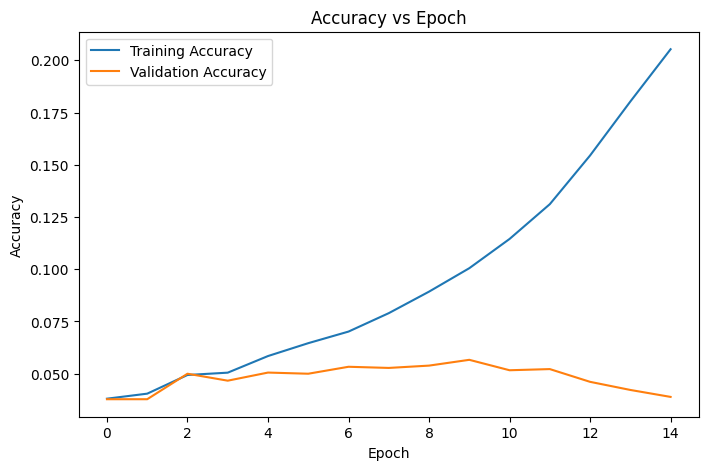

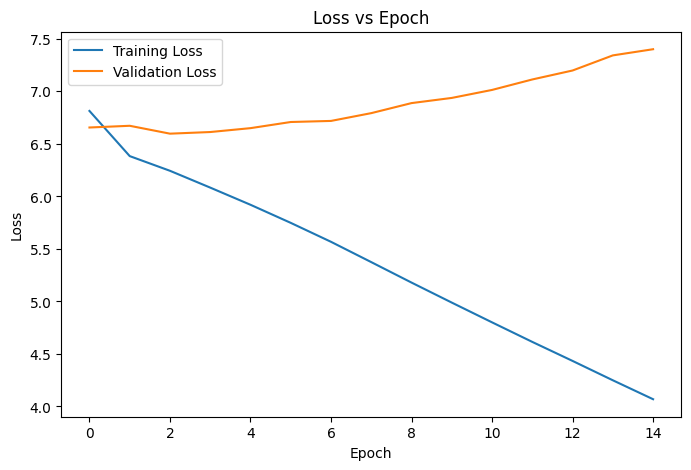

In [3]:
# 24BAD083 - Noel George
# PART C: Train the model and visualize training curves

import matplotlib.pyplot as plt

EPOCHS = 15

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=128,
    verbose=1
)

print("\nFinal Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])
print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

# Accuracy vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss vs Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## PART D: TEXT GENERATION AND EXPERIMENT MANAGEMENT

In [4]:
# 24BAD083 - Noel George
# PART D: Generate text from seed words

def generate_text(seed_text, next_words=30, seq_length=seq_length):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=seq_length, padding="pre")
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# Generate multiple samples with different seed inputs
seed_words = ["to be or not", "the king said", "my lord"]

for seed in seed_words:
    generated = generate_text(seed, next_words=25)
    print("Seed:", seed)
    print("Generated:", generated)
    print("-" * 80)

Seed: to be or not
Generated: to be or not he is that to the people of the common which i have not consul to the people of the market place of the capitol the
--------------------------------------------------------------------------------
Seed: the king said
Generated: the king said the people of rome of which and cities be so in a voices of the state of the people of the people and that not
--------------------------------------------------------------------------------
Seed: my lord
Generated: my lord and is he is as than that i will known you are not menenius to the capitol of the people of the people of the
--------------------------------------------------------------------------------
